


# CMEMS: Marine Data 4 Macaronesia Area

<div style="text-align: right"><i> </i></div>

***
<center><h1> Analysing the Macaronesian Sea Surface Temperature, and Currents </h1></center>

***


# Table of contents

- [1. Introduction](#1.-Introduction)
- [2. Set up Python](#2.-Set-up-Python)
    - [2.1 Required Python modules](#2.1-Required-Python-modules)
- [3. Data](#3.-Data)
    - [3.1 Presentation of the product used](#3.1-Presentation-of-the-product-used)
    - [3.2 Accessing the data](#3.2-Accessing-the-data)
- [4. Seasonal Patterns of Currents and Sea Surface Temperatures](#4.-Seasonal-Patterns-of-Currents-and-sea-Surface-Temperatures)
- [5. Long Term Trends in the Area of Study](#5.-Long-Term-Trends-in-the-Area-of-Study)
    - [5.1 Current Dynamics](#5.1-Current-Dynamics)
    - [5.2 Sea Surface Temperatures](#5.2-Sea-Surface-Temperatures)


# 1. Introduction

[Go back to the "Table of contents"](#Table-of-contents)

The notebook analyses the sea surface temperature and surface currents in the European Macaronesia Area.

 We will analyse how these variables interact with each other and what are the long-term trends associated with them.
    
# 2. Set up Python

[Go back to the "Table of contents"](#Table-of-contents)

## 2.1 Required Python modules
[Go back to the "Table of contents"](#Table-of-contents)

The Jupyter Notebook must be set up with all the necessary available tools from the Jupyter Notebook ecosystem. Here is the list of the modules we will be using in this notebook.

| Module name | Description |
| :---: | :---|
| **numpy** | [NumPy](https://numpy.org/) is the fundamental package for scientific computing with Python and for managing ND-arrays.|
|**pandas**| [Pandas](https://pandas.pydata.org/docs/) is a powerful package to manage with data tables.|
| **xarray** | [Xarray](http://xarray.pydata.org/en/stable/) is a very user friendly library to manipulate NetCDF files within Python. It introduces labels in the form of dimensions, coordinates and attributes on top of raw NumPy-like arrays, which allows for a more intuitive, more concise, and less error-prone developer experience. |
| **scipy** | [SciPy](https://scipy.org/) is an open-source Python library used for scientific and technical computing, providing tools for mathematics, statistics, optimization, and signal processing, making it essential for data analysis and complex computations. |
| **matplotlib** |[Matplotlib](https://matplotlib.org/) is a Python 2D plotting library which produces high quality figures. |
| **cartopy** |[Cartopy](https://scitools.org.uk/cartopy/docs/latest/) is a library for plotting maps and geospatial data analyses in Python. |
| **datetime** |[Datetime](https://docs.python.org/3/library/datetime.html) supplies classes for manipulating dates and times |


In [ ]:
# To avoid warning messages
import warnings
warnings.filterwarnings('ignore')

# Import libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import datetime
import pandas as pd
import os

from scipy.stats import linregress, pearsonr
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# 3. Data

[Go back to the "Table of contents"](#Table-of-contents)

## 3.1 Presentation of the product used

[Go back to the "Table of contents"](#Table-of-contents)


----------------

We will derive the sea water temperature and the currents from a reanalysis product from the CMEMS catalogue : [Global Ocean Physics Reanalysis](https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_PHY_001_030/description).

This system mainly relies on the real-time global forecasting model from CMEMS. It uses the NEMO platform, which is driven at the surface by ECMWF ERA-Interim data, later replaced by ERA5 for recent years. Observations are incorporated using a simplified Kalman filter. It assimilates data from satellite altimeters (Sea Level Anomaly), Sea Surface Temperature, Sea Ice Concentration, and in-situ temperature and salinity profiles. Additionally, a 3D-VAR scheme helps correct slow-developing large-scale biases in temperature and salinity.

The table below summarizes the main characteristics of the dataset :

| Parameter | Value |
| :---: | :---|
| **Variables used** | thetao, uo, vo |
| **Product identifier** |[GLOBAL_MULTIYEAR_PHY_001_030](https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_PHY_001_030/description) |
| **Spatial resolution** | 0.083° × 0.083° |
| **Temporal resolution** | Daily, Monthly |
| **Temporal coverage** | 1 Jan 1993 to 28 Jan 2025 |


<center><img src="./img/global_ocean_rean.png" width="300"></center>


In our case, we will only use **monthly** data. It will allow us to study the trends across the 30 years of data available, while maintaining manageable file sizes.

**For detailed information about the product, please consult the document:** [Product User Manual (PUM)](https://documentation.marine.copernicus.eu/PUM/CMEMS-GLO-PUM-001-030.pdf)

**For information about the quality of the product, please consult the document:** [Quality Information Document (QUID)](https://documentation.marine.copernicus.eu/QUID/CMEMS-GLO-QUID-001-030.pdf)



## 3.2 Accessing the data 

[Go back to the "Table of contents"](#Table-of-contents)

In [2]:
import copernicusmarine

**Coordinates**

In [3]:
# In this sell, we define the boundaries of our area of interest

lat_min = 25
lat_max = 41
lon_min = -33
lon_max = -12



**SST and currents**

In [ ]:
sstCurrentsMacaronesia1993_2025 = copernicusmarine.open_dataset(          
 dataset_id="cmems_mod_glo_phy_my_0.083deg_P1M-m",          
 variables=[ "thetao", "uo", "vo"],
 minimum_longitude=lon_min,
 maximum_longitude=lon_max,
 minimum_latitude=lat_min,
 maximum_latitude=lat_max,
 start_datetime="1993-01-01T00:00:00",
 end_datetime="2025-11-01T00:00:00",    #01/11/2025    prima 2023-12-31T00:00:00
 #minimum_depth=0,
 maximum_depth=0.5
)

INFO - 2026-01-26T11:08:26Z - Selected dataset version: "202311"
INFO - 2026-01-26T11:08:26Z - Selected dataset part: "default"


**Save dataset**

In [14]:
sstCurrentsMacaronesia1993_2025.to_netcdf("sstCurrentsMacaronesia1993_2025.nc")

# 4. Seasonal Patterns of Currents and Sea Surface Temperatures

[Go back to the "Table of contents"](#Table-of-contents)



In [4]:
ds = xr.open_dataset('sstCurrentsMacaronesia1993_2025.nc')
ds

<xarray.Dataset> Size: 463MB
Dimensions:    (depth: 1, latitude: 193, longitude: 253, time: 395)
Coordinates:
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 772B 25.0 25.08 25.17 ... 40.83 40.92 41.0
  * longitude  (longitude) float32 1kB -33.0 -32.92 -32.83 ... -12.08 -12.0
  * time       (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2025-11-01
Data variables:
    thetao     (time, depth, latitude, longitude) float64 154MB ...
    uo         (time, depth, latitude, longitude) float64 154MB ...
    vo         (time, depth, latitude, longitude) float64 154MB ...
Attributes:
    contact:      servicedesk.cmems@mercator-ocean.eu
    producer:     CMEMS - Global Monitoring and Forecasting Centre
    Conventions:  CF-1.6
    title:        Monthly mean fields for product GLOBAL_REANALYSIS_PHY_001_030
    credit:       E.U. Copernicus Marine Service Information (CMEMS)
    institution:  Mercator Ocean
    source:       MERCATOR GLORYS12V1
    references:   http://marine.copernicus.eu

The dataset has 4 dimensions : depth, latitude, longitude and time. However, we retrieved only one depth level from the product : 0.5 meters beneath the surface. It is therefore not useful to keep this "depth" dimension in the dataset. To simplify an xarray dataset that has dimensions with single levels, use the **squeeze** method.

In [5]:
ds = ds.squeeze()
ds

<xarray.Dataset> Size: 463MB
Dimensions:    (latitude: 193, longitude: 253, time: 395)
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 772B 25.0 25.08 25.17 ... 40.83 40.92 41.0
  * longitude  (longitude) float32 1kB -33.0 -32.92 -32.83 ... -12.08 -12.0
  * time       (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2025-11-01
Data variables:
    thetao     (time, latitude, longitude) float64 154MB ...
    uo         (time, latitude, longitude) float64 154MB ...
    vo         (time, latitude, longitude) float64 154MB ...
Attributes:
    contact:      servicedesk.cmems@mercator-ocean.eu
    producer:     CMEMS - Global Monitoring and Forecasting Centre
    Conventions:  CF-1.6
    title:        Monthly mean fields for product GLOBAL_REANALYSIS_PHY_001_030
    credit:       E.U. Copernicus Marine Service Information (CMEMS)
    institution:  Mercator Ocean
    source:       MERCATOR GLORYS12V1
    references:   http://marine.copernicus.eu

To complete our dataset, we will compute the total current velocity by combining the eastward and northward components, using the following formula :

Current Speed= $\sqrt{uo²+vo²}$
   

In [32]:
ds['cur_speed'] = np.sqrt(ds.uo**2 + ds.vo**2)

In [35]:
ds

<xarray.Dataset> Size: 617MB
Dimensions:    (latitude: 193, longitude: 253, time: 395)
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 772B 25.0 25.08 25.17 ... 40.83 40.92 41.0
  * longitude  (longitude) float32 1kB -33.0 -32.92 -32.83 ... -12.08 -12.0
  * time       (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2025-11-01
Data variables:
    thetao     (time, latitude, longitude) float64 154MB 22.16 22.13 ... 17.86
    uo         (time, latitude, longitude) float64 154MB -0.07813 ... 0.06958
    vo         (time, latitude, longitude) float64 154MB 0.02075 ... -0.01404
    cur_speed  (time, latitude, longitude) float64 154MB 0.08084 ... 0.07098
Attributes:
    contact:      servicedesk.cmems@mercator-ocean.eu
    producer:     CMEMS - Global Monitoring and Forecasting Centre
    Conventions:  CF-1.6
    title:        Monthly mean fields for product GLOBAL_REANALYSIS_PHY_001_030
    credit:       E.U. Copernicus Marine Service Information (CMEMS)
    institution:  Mercator Ocean
    source:       MERCATOR GLORYS12V1
    references:   http://marine.copernicus.eu

In order to highlight seasonal patterns, one thing we can do is compute 4 different climatologies over 30 years of data available : for Summer, Fall, Winter and Spring. In order to do this, it is possible to compute the seasonal means of the dataset using only the **groupby** function. Xarray will automatically group together winter months, summer months, etc.

In [18]:
ds_seas = ds.groupby("time.season").mean()
ds_seas

<xarray.Dataset> Size: 6MB
Dimensions:    (season: 4, latitude: 193, longitude: 253)
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 772B 25.0 25.08 25.17 ... 40.83 40.92 41.0
  * longitude  (longitude) float32 1kB -33.0 -32.92 -32.83 ... -12.08 -12.0
  * season     (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Data variables:
    thetao     (season, latitude, longitude) float64 2MB 22.95 22.93 ... 19.03
    uo         (season, latitude, longitude) float64 2MB -0.03733 ... 0.005937
    vo         (season, latitude, longitude) float64 2MB -0.005456 ... -0.03067
    cur_speed  (season, latitude, longitude) float64 2MB 0.07327 ... 0.06753
Attributes:
    contact:      servicedesk.cmems@mercator-ocean.eu
    producer:     CMEMS - Global Monitoring and Forecasting Centre
    Conventions:  CF-1.6
    title:        Monthly mean fields for product GLOBAL_REANALYSIS_PHY_001_030
    credit:       E.U. Copernicus Marine Service Information (CMEMS)
    institution:  Mercator Ocean
    source:       MERCATOR GLORYS12V1
    references:   http://marine.copernicus.eu

The time coordinate has been replaced by a "season" coordinate, with 4 values : DJF (December Janury February : Winter), JJA (June July August : Summer), MAM (March April May : Spring), SON (September October November  : Fall).

Lets visualize the computed climatologies.

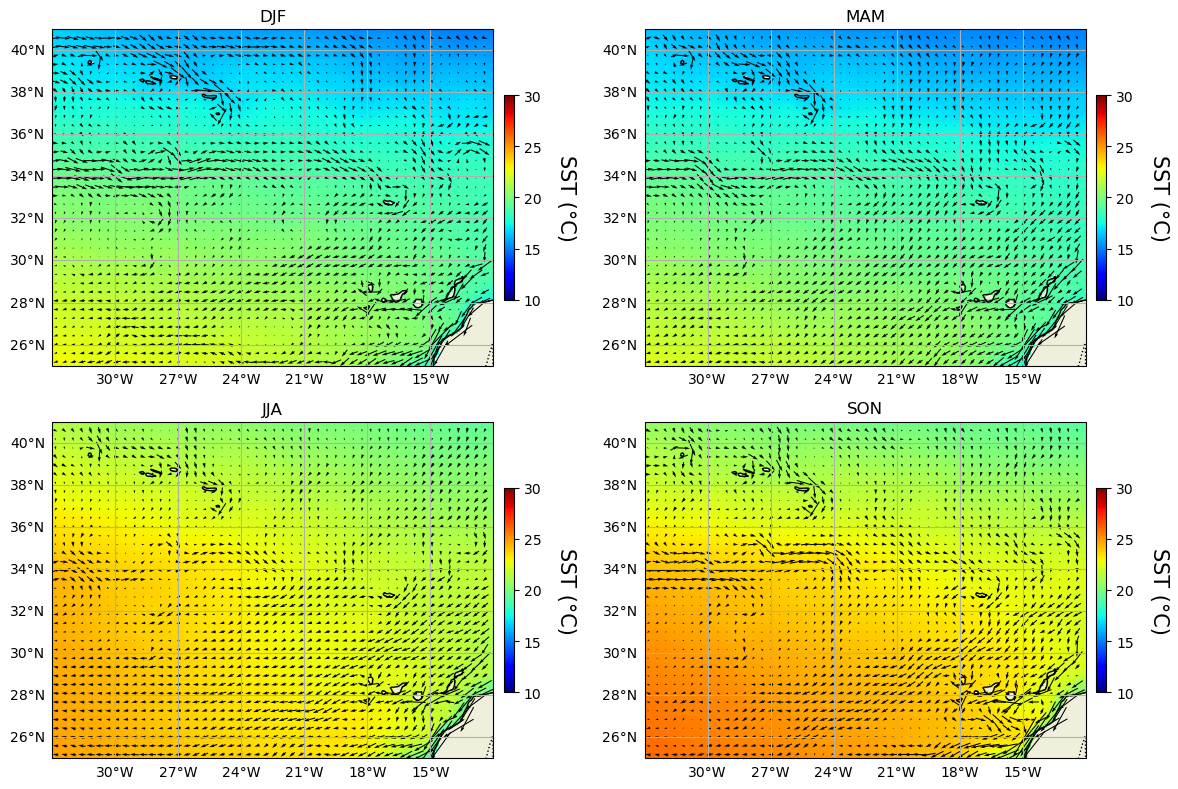

In [58]:
# display seasonal current patterns

f = plt.figure(figsize=(12,8))


seasons = ["DJF", "MAM", "JJA", "SON"]

ds_seas_coarse = ds_seas.coarsen(latitude=5, longitude=5, boundary="trim").mean()
x = ds_seas_coarse.longitude.data
y = ds_seas_coarse.latitude.data

for c, season in enumerate(seasons):

    ax = plt.subplot(2,2,c+1, projection = ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.LAND, zorder=1, edgecolor='k')                            
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    gl.right_labels = False                                                            
    gl.top_labels = False 
    ax.set_ylabel('Latitude (°)')
    ax.set_ylabel('Longitude (°)')
    
    im = ax.pcolor(ds_seas.longitude.data, ds_seas.latitude.data, ds_seas.sel(season=season).thetao.data, cmap='jet', vmin=10, vmax=30)
    cbar = f.colorbar(im, ax=ax,fraction=0.02, pad=0.02)                                            # add the colorbar
    cbar.set_label('SST (°C)', rotation=270,fontsize=15, labelpad=25)
    ax.set_title(f'{season}')
    
    qv = ax.quiver(x, y, ds_seas_coarse.sel(season=season)["uo"], ds_seas_coarse.sel(season=season)["vo"], pivot='mid', angles='xy')

plt.tight_layout()

f.savefig('fig/SeasonalSSTcurrent.svg')
f.savefig('fig/SeasonalSSTcurrent.pdf')
f.savefig('fig/SeasonalSSTcurrent.png')

**Different color palette**

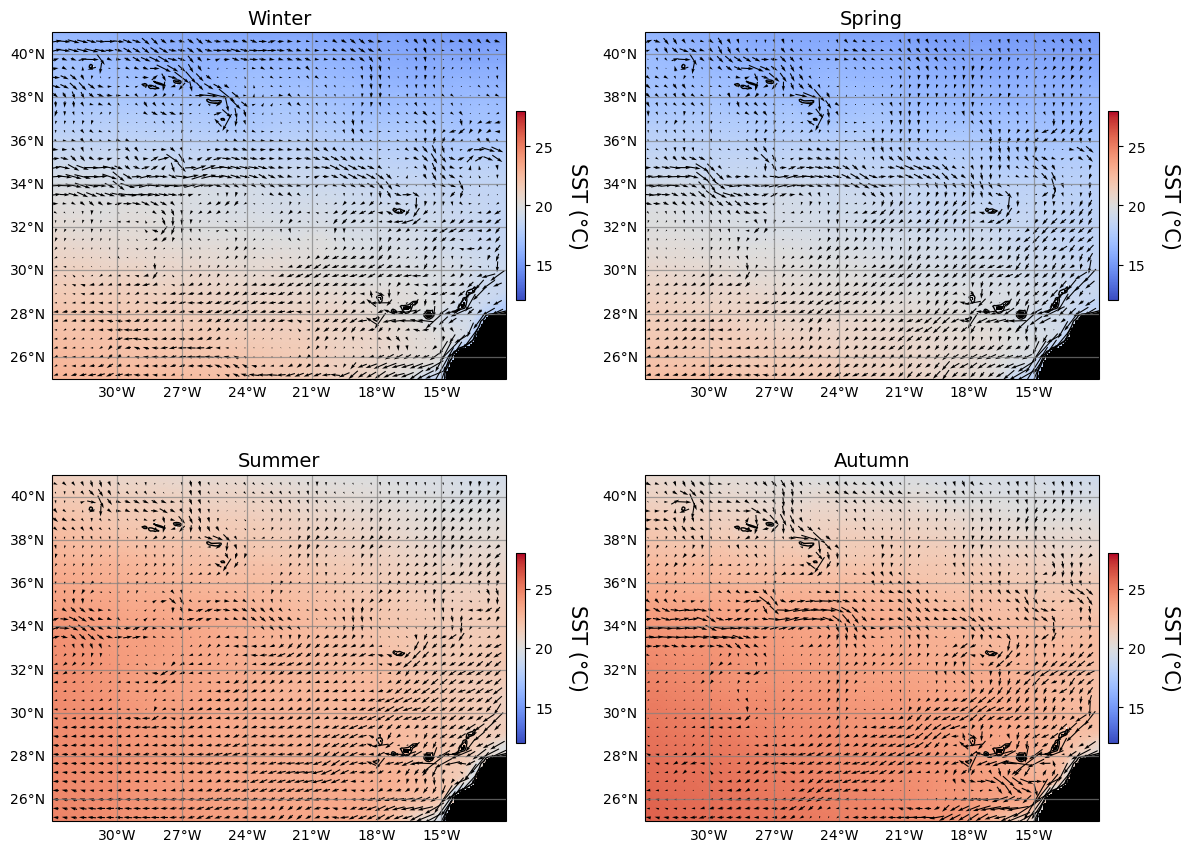

In [60]:
# display seasonal current patterns

f = plt.figure(figsize=(12,9))


seasons = ["DJF", "MAM", "JJA", "SON"]
# Dictionary seasons
seasons_name = {
    'DJF': 'Winter',
    'MAM': 'Spring',
    'JJA': 'Summer',
    'SON': 'Autumn'
}

seasons = list(seasons_name.keys())

ds_seas_coarse = ds_seas.coarsen(latitude=5, longitude=5, boundary="trim").mean()
x = ds_seas_coarse.longitude.data
y = ds_seas_coarse.latitude.data

for c, season in enumerate(seasons):

    ax = plt.subplot(2,2,c+1, projection = ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.LAND, zorder=1, edgecolor='w', facecolor='k')                            
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.9, color='gray', alpha=0.7)
    gl.right_labels = False                                                            
    gl.top_labels = False 
    ax.set_ylabel('Latitude (°)')
    ax.set_ylabel('Longitude (°)')
    
    im = ax.pcolor(ds_seas.longitude.data, ds_seas.latitude.data, ds_seas.sel(season=season).thetao.data, cmap='coolwarm', vmin=12, vmax=28)
    cbar = f.colorbar(im, ax=ax,fraction=0.02, pad=0.02)                                            # add the colorbar
    cbar.set_label('SST (°C)', rotation=270,fontsize=15, labelpad=25)
    ax.set_title(f"{seasons_name[season]}", fontsize=14)    
    
   

    qv = ax.quiver(x, y, ds_seas_coarse.sel(season=season)["uo"], ds_seas_coarse.sel(season=season)["vo"], pivot='mid', angles='xy')     #color='w'
plt.savefig('fig/BluRedTempCurrFrecce.pdf')
plt.savefig('fig/BluRedTempCurrFrecce.svg')
plt.savefig('fig/BluRedTempCurrFrecce.png')
plt.tight_layout()

On the plots, the arrows show the currents and the colors show the Sea Surface Temperature. 

# 5. Long Term Trends in the Area of Study

[Go back to the "Table of contents"](#Table-of-contents)


In this sections, we will look at the trends in SST, and current velocity. This will allow us to evaluate the potentials impacts of climate change in the region: potential rise of the temperatures, and shifting of the current dynamics.

In order to highlight long-term trends, we can smooth out the seasonal pattern of the data by resampling the monthly dataset and compute the yearly means of SST,  and current speed. 

In [36]:
ds_avg_y = ds.mean(dim=['latitude','longitude']).groupby('time.year').mean()



## 5.1 Current Dynamics

[Go back to the "Table of contents"](#Table-of-contents)


Using the linear regression module from **scipy**, we now compute the linear trends for the current variables : horizontal component, vertical component and total speed. The **linregress** function will also yield the correlation coefficient and p-value to evaluate the significance of the trend. You can read the associated [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html) to know more about the function and its outputs.

In [33]:
slope1, intercept1, r1, p1, se1 = linregress(ds_avg_y.year.data,  ds_avg_y.cur_speed.data)
slope2, intercept2, r2, p2, se2 = linregress(ds_avg_y.year.data,  ds_avg_y.uo.data)
slope3, intercept3, r3, p3, se3 = linregress(ds_avg_y.year.data,  ds_avg_y.vo.data)

trend_vals1 = ds_avg_y.year.data*slope1 + intercept1
trend_vals2 = ds_avg_y.year.data*slope2 + intercept2
trend_vals3 = ds_avg_y.year.data*slope3 + intercept3


In [36]:
print(slope1, intercept1, r1, p1, se1)
print(slope2, intercept2, r2, p2, se2)
print(slope3, intercept3, r3, p3, se3)

-4.503694620020962e-05 0.18645348580570145 -0.1088732001502857 0.5464351095105642 7.385464170072641e-05
-1.3285002738245827e-05 0.015564779490950696 -0.027436772249834193 0.8795313744297694 8.693291815358795e-05
4.633939568736471e-06 -0.031152755364383403 0.013180062582502665 0.941967393824166 6.314141667332884e-05


In [43]:
print(p1, p2, p3)

0.5464351095105642 0.8795313744297694 0.941967393824166


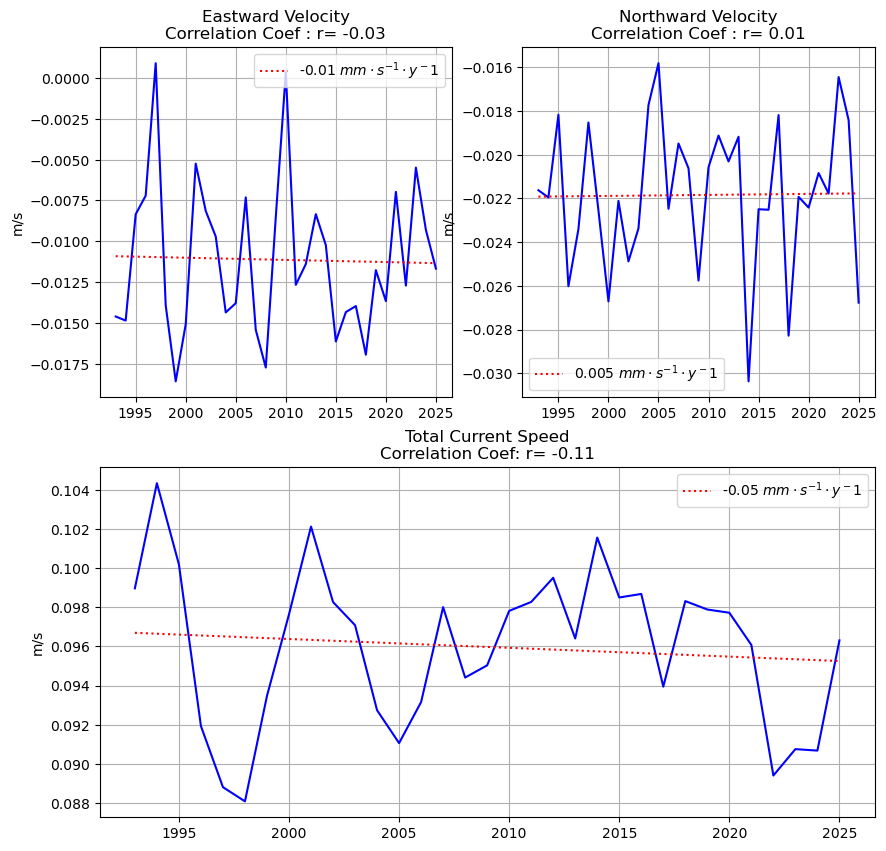

In [83]:
fig = plt.figure(figsize=(10, 10))

ax1 = plt.subplot(221)
ax1.plot(ds_avg_y.year.data, ds_avg_y.uo.data, color='b')
ax1.plot(ds_avg_y.year.data, trend_vals2, color='r', linestyle=':', label='%.2f $mm\cdot s^{-1}\cdot{y^-1}$' % (1000*slope2))
ax1.set_title('Eastward Velocity\nCorrelation Coef : r= %.2f' %r2)
ax1.set_ylabel('m/s')
ax1.grid(True)
ax1.legend()

ax2 = plt.subplot(222)
ax2.plot(ds_avg_y.year.data, ds_avg_y.vo.data, color='b')
ax2.plot(ds_avg_y.year.data, trend_vals3, color='r', linestyle=':', label='%.3f $mm \cdot s^{-1}\cdot{y^-1}$' % (1000*slope3))
ax2.set_title('Northward Velocity\nCorrelation Coef : r= %.2f' %r3)
ax2.set_ylabel('m/s')
ax2.grid(True)
ax2.legend()


ax3 = plt.subplot(212)
ax3.plot(ds_avg_y.year.data, ds_avg_y.cur_speed.data, color='b')
ax3.plot(ds_avg_y.year.data, trend_vals1, color='r', linestyle=':', label='%.2f $mm \cdot s^{-1}\cdot{y^-1}$' % (1000*slope1))
ax3.set_title('Total Current Speed\nCorrelation Coef: r= %.2f' %r1)    #; p= %.2f %p1
ax3.set_ylabel('m/s')
ax3.grid(True)
ax3.legend()

fig.savefig('LongTermCurrents.svg')
fig.savefig('LongTermCurrents.pdf')
fig.savefig('LongTermCurrents.png')


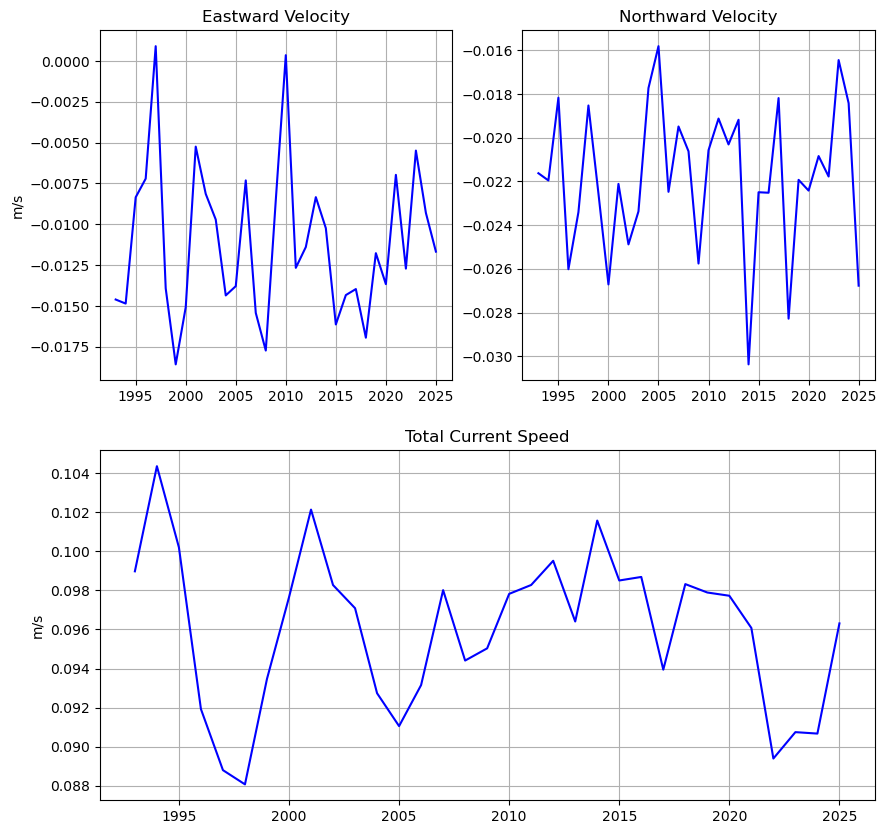

In [79]:
fig = plt.figure(figsize=(10, 10))

ax1 = plt.subplot(221)
ax1.plot(ds_avg_y.year.data, ds_avg_y.uo.data, color='b')
#ax1.plot(ds_avg_y.year.data, trend_vals2, color='b', linestyle=':', label='%.2f $mm\cdot s^{-1}\cdot{y^-1}$' % (1000*slope2))
ax1.set_title('Eastward Velocity')   #\nCorrelation Coef : r= %.2f' %r2
ax1.set_ylabel('m/s')
ax1.grid(True)
#ax1.legend()

ax2 = plt.subplot(222)
ax2.plot(ds_avg_y.year.data, ds_avg_y.vo.data, color='b')
#ax2.plot(ds_avg_y.year.data, trend_vals3, color='b', linestyle=':', label='%.3f $mm \cdot s^{-1}\cdot{y^-1}$' % (1000*slope3))
ax2.set_title('Northward Velocity') #\nCorrelation Coef : r= %.2f' %r3
#ax2.set_ylabel('m/s')
ax2.grid(True)
#ax2.legend()


ax3 = plt.subplot(212)
ax3.plot(ds_avg_y.year.data, ds_avg_y.cur_speed.data, color='b')
#ax3.plot(ds_avg_y.year.data, trend_vals1, color='b', linestyle=':', label='%.2f $mm \cdot s^{-1}\cdot{y^-1}$' % (1000*slope1))
ax3.set_title('Total Current Speed')    #; p= %.2f %p1   \nCorrelation Coef: r= %.2f' %r1
ax3.set_ylabel('m/s')
ax3.grid(True)
#ax3.legend()

fig.savefig('fig/NoRegresLineLongTermCurrents.svg')
fig.savefig('fig/NoRegresLineLongTermCurrents.pdf')
fig.savefig('fig/NoRegresLineLongTermCurrents.png')

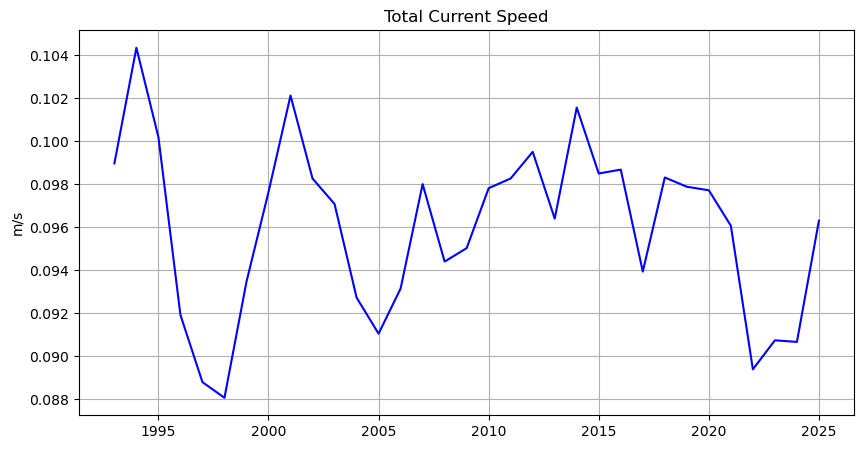

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))



ax.plot(ds_avg_y.year.data, ds_avg_y.cur_speed.data, color='b')
#ax3.plot(ds_avg_y.year.data, trend_vals1, color='b', linestyle=':', label='%.2f $mm \cdot s^{-1}\cdot{y^-1}$' % (1000*slope1))
ax.set_title('Total Current Speed')    #; p= %.2f %p1   \nCorrelation Coef: r= %.2f' %r1
ax.set_ylabel('m/s')
ax.grid(True)
#ax3.legend()
plt.tight_layout()
#fig.savefig('fig/TemperatureLongTermCurrentSpeed.svg')
#fig.savefig('fig/TemperatureLongTermCurrentSpeed.pdf')
#fig.savefig('fig/TemperatureLongTermCurrentSpeed.png')

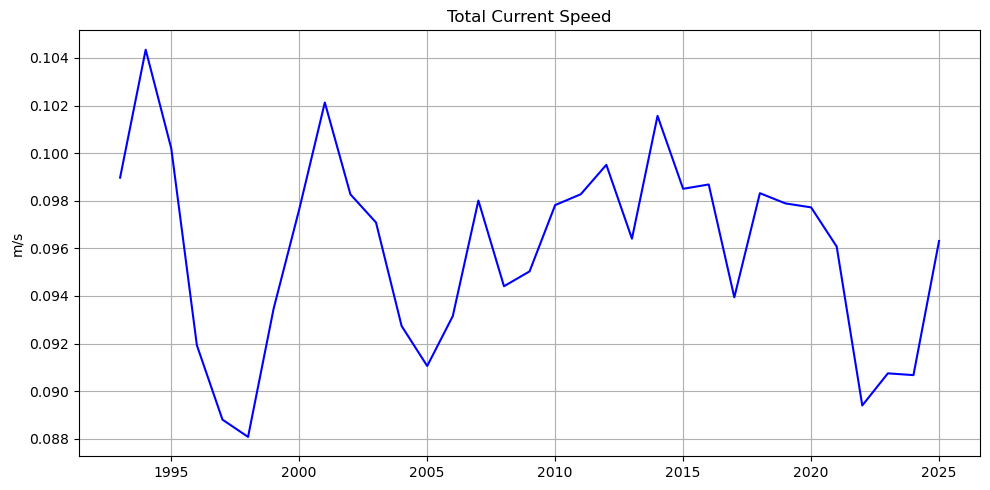

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(ds_avg_y.year.data, ds_avg_y.cur_speed.data, color='b')
#ax3.plot(ds_avg_y.year.data, trend_vals1, color='b', linestyle=':', label='%.2f $mm \cdot s^{-1}\cdot{y^-1}$' % (1000*slope1))
ax.set_title('Total Current Speed')    #; p= %.2f %p1   \nCorrelation Coef: r= %.2f' %r1
ax.set_ylabel('m/s')
ax.grid(True)
#ax3.legend()
plt.tight_layout()
#fig.savefig('fig/TemperatureLongTermCurrentSpeed.svg')
#fig.savefig('fig/TemperatureLongTermCurrentSpeed.pdf')
#fig.savefig('fig/TemperatureLongTermCurrentSpeed.png')

## 5.2 Sea Surface Temperatures

[Go back to the "Table of contents"](#Table-of-contents)

***Coordinates AZORES***

In [137]:
lat_minAzores = 35
lat_maxAzores = 41
lon_minAzores = -33
lon_maxAzores = -21

***Coordinates MADEIRA***

In [138]:
lat_minMadeira = 31
lat_maxMadeira = 35
lon_minMadeira = -21
lon_maxMadeira = -13

***Coordinates CANARY ISLANDS***

In [139]:
lat_minCanary = 26
lat_maxCanary = 31
lon_minCanary = -21
lon_maxCanary = -12

In [156]:
ds['thetao'].max().values

array(27.68208868)

In [157]:
print(f"Min: {ds['thetao'].min().values}")
print(f"Max: {ds['thetao'].max().values}")
print(f"Mean: {ds['thetao'].mean().values}")
print(f"Std: {ds['thetao'].std().values}")
print(f"Median: {ds['thetao'].median().values}")

Min: 12.678701139986515
Max: 27.682088680565357
Mean: 20.754465911864575
Std: 2.7715574632674334
Median: 20.846919156610966


In [159]:
import numpy as np

# Find absolute min and max values
min_val = ds['thetao'].min(skipna=True).values
max_val = ds['thetao'].max(skipna=True).values

print(f"Absolute minimum temperature: {min_val:.4f}°C")
print(f"Absolute maximum temperature: {max_val:.4f}°C")

# Find where these values occur
min_location = ds['thetao'].where(ds['thetao'] == min_val, drop=True)
max_location = ds['thetao'].where(ds['thetao'] == max_val, drop=True)

print("\n" + "="*60)
print("MINIMUM TEMPERATURE LOCATION:")
print("="*60)
if len(min_location.time) > 0:
    print(f"Time: {min_location.time.values}")
    #print(f"Depth: {min_location.depth.values}")
    print(f"Latitude: {min_location.latitude.values}")
    print(f"Longitude: {min_location.longitude.values}")
    #print(f"Temperature: {min_location.values[0]:.4f}°C")
else:
    print("No exact match found (floating point precision issue)")

print("\n" + "="*60)
print("MAXIMUM TEMPERATURE LOCATION:")
print("="*60)
if len(max_location.time) > 0:
    print(f"Time: {max_location.time.values}")
    #print(f"Depth: {max_location.depth.values}")
    print(f"Latitude: {max_location.latitude.values}")
    print(f"Longitude: {max_location.longitude.values}")
    #print(f"Temperature: {max_location.values[0]:.4f}°C")
else:
    print("No exact match found (floating point precision issue)")

Absolute minimum temperature: 12.6787°C
Absolute maximum temperature: 27.6821°C

MINIMUM TEMPERATURE LOCATION:
Time: ['1994-02-01T00:00:00.000000000']
Latitude: [41.]
Longitude: [-13.416667]

MAXIMUM TEMPERATURE LOCATION:
Time: ['2023-10-01T00:00:00.000000000']
Latitude: [25.]
Longitude: [-31.916666]


In [140]:
SST_Azores = ds['thetao'].sel(
    latitude=slice(lat_minAzores, lat_maxAzores), 
    longitude=slice(lon_minAzores, lon_maxAzores)
    ).mean(dim=["latitude", "longitude"])

SST_Madeira = ds['thetao'].sel(
    latitude=slice(lat_minMadeira, lat_maxMadeira), 
    longitude=slice(lon_minMadeira, lon_maxMadeira)
    ).mean(dim=["latitude", "longitude"])


SST_Canary = ds['thetao'].sel(
    latitude=slice(lat_minCanary, lat_maxCanary), 
    longitude=slice(lon_minCanary, lon_maxCanary)
    ).mean(dim=["latitude", "longitude"])

In [166]:
print(SST_Azores.min(skipna=True).values)
print(SST_Azores.max(skipna=True).values)
print(SST_Madeira.min(skipna=True).values)
print(SST_Madeira.max(skipna=True).values)
print(SST_Canary.min(skipna=True).values)
print(SST_Canary.max(skipna=True).values)


15.307955882161451
25.545953732500546
16.971773121821517
24.821863263718285
17.922210706001156
25.12681973740351


In [169]:
SST_Azores.idxmax().values

numpy.datetime64('2024-08-01T00:00:00.000000000')

In [ ]:
SST_list = [SST_Azores, SST_Madeira, SST_Canary]

archipelagos = ["Azores", "Madeira", "Canary"]
colors = ["blue", "green", "orange"]

In [142]:
import hvplot
import hvplot.xarray 
hvplot.extension('bokeh')  # oppure 'plotly' se preferisci
import holoviews 
import panel

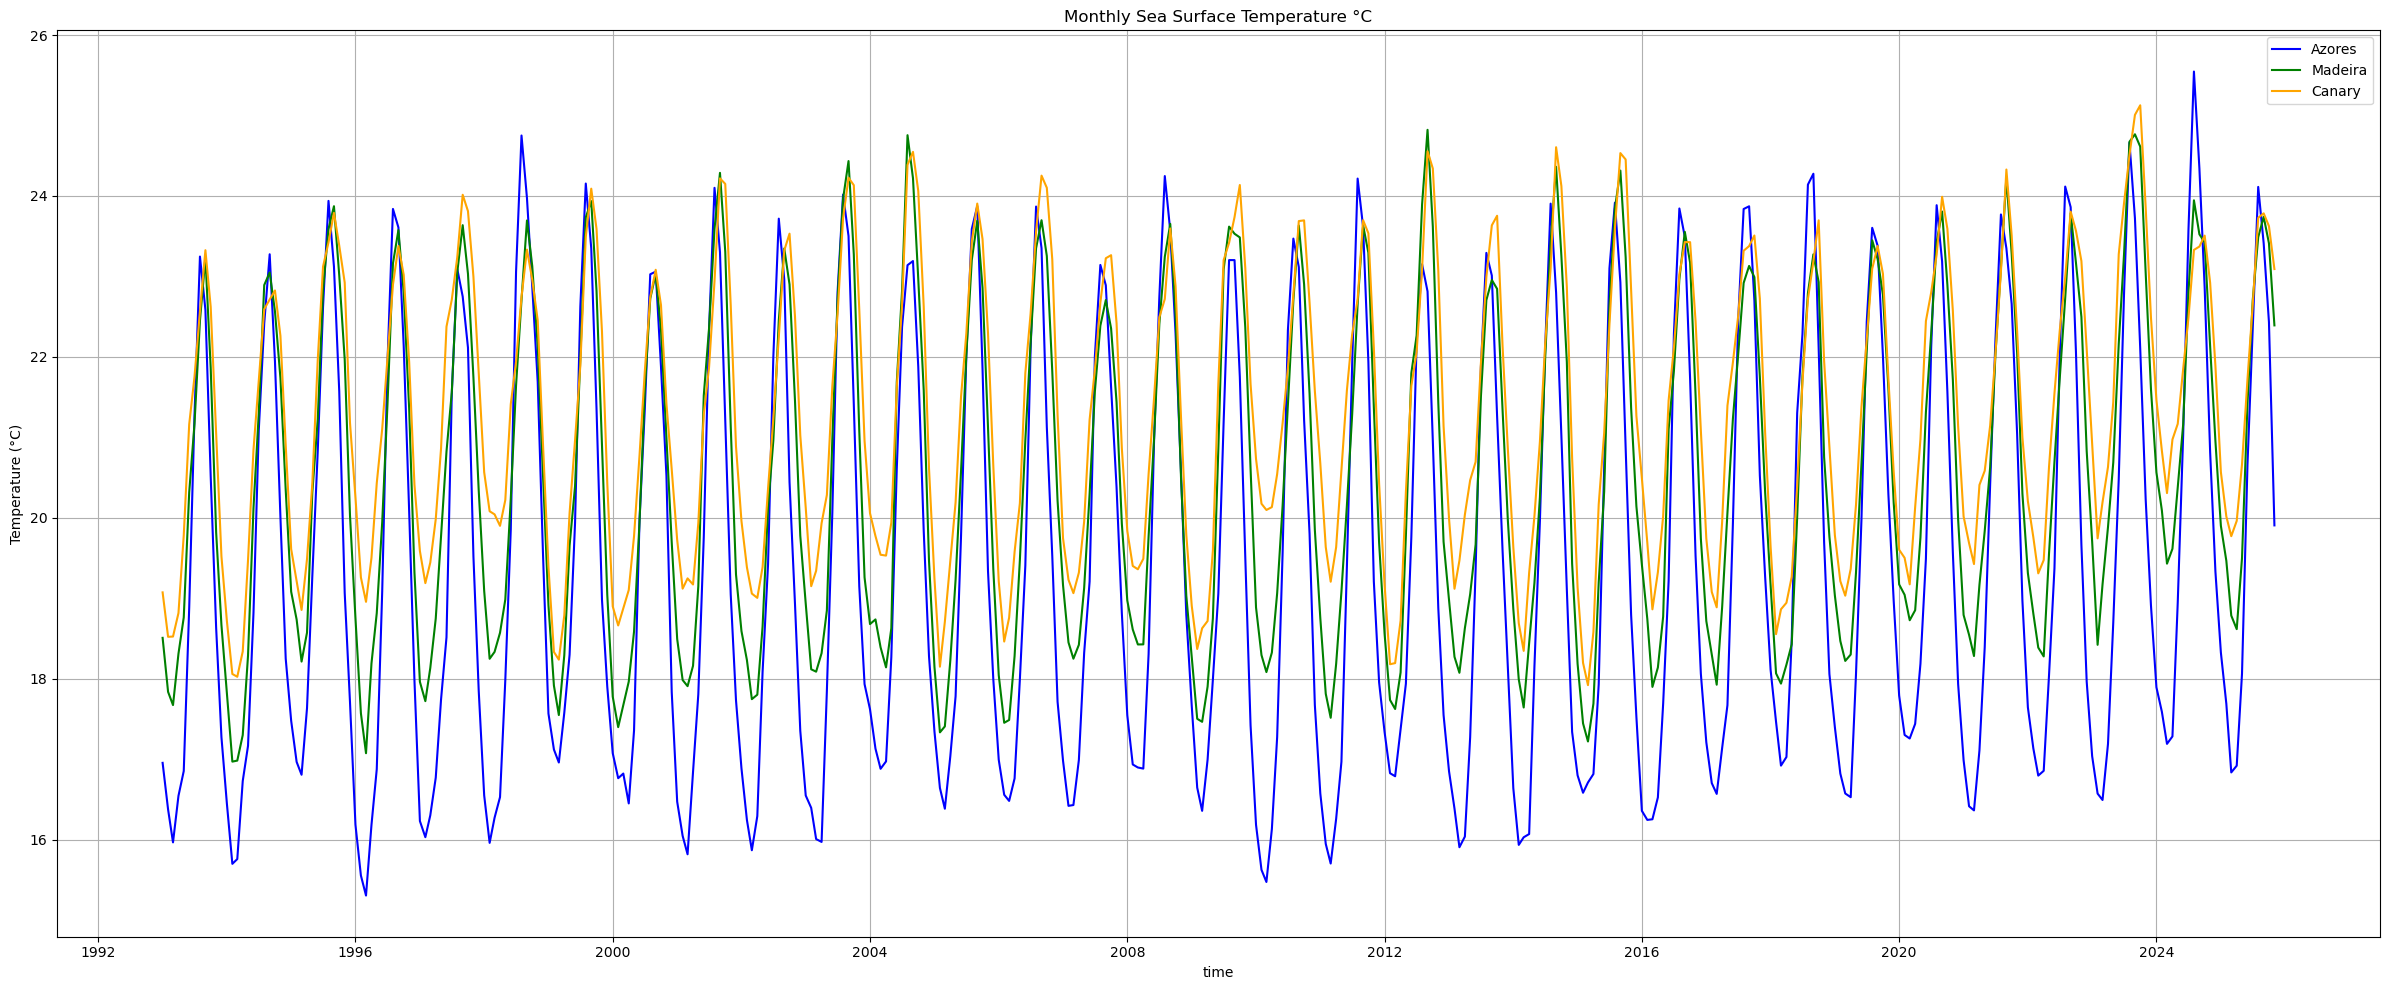

In [143]:
plt.figure(figsize=(24, 10))

for sst_vals, archi, color in zip(SST_list, archipelagos, colors):
    
    plt.plot(sst_vals['time'], sst_vals, label=archi, color=color)

#plt.gca().invert_yaxis()
plt.title("Monthly Sea Surface Temperature °C")
plt.xlabel("time")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.legend()
plt.tight_layout()
#plt.savefig("MonthlySSTAzoresMadeiraCanary.png")
plt.show()

In [12]:
from scipy import stats

In [13]:
temp_avg = ds['thetao'].mean(dim=['latitude', 'longitude'])

In [14]:
tmax_annual = temp_avg.groupby('time.year').max()
tmin_annual = temp_avg.groupby('time.year').min()

In [21]:
tmax_annual

<xarray.DataArray 'thetao' (year: 33)> Size: 264B
array([23.42559937, 23.55759872, 24.20955808, 23.80738082, 23.91612228,
       24.10439265, 24.1312074 , 23.46583574, 24.31754197, 23.61216681,
       24.46620059, 24.48129473, 24.0273582 , 24.00345422, 23.24988124,
       23.84218627, 23.88009738, 23.87553203, 23.98642976, 24.31039459,
       23.31903008, 24.2842249 , 24.32711721, 23.91157356, 23.87263511,
       23.95372966, 24.01640582, 24.00117404, 24.2782446 , 24.14750158,
       25.04593049, 24.81276421, 24.04637424])
Coordinates:
    depth    float32 4B 0.494
  * year     (year) int64 264B 1993 1994 1995 1996 1997 ... 2022 2023 2024 2025

In [22]:
years_tmax = tmax_annual.year.data
slope_max, intercept_max, r_max, p_max, se_max = linregress(
    years_tmax, tmax_annual.data
)

In [23]:
print(slope_max, intercept_max, r_max, p_max, se_max)

0.015927289704614853 -7.97710870247435 0.39512065249996703 0.022859790488319688 0.006650764416457568


In [ ]:
years_tmin = tmin_annual.year.data
slope_min, intercept_min, r_min, p_min, se_min = linregress(
    years_tmin, tmin_annual.data
)

In [18]:
print(slope_min, intercept_min, r_min, p_min, se_min)

0.025797947691079712 -33.768150697016964 0.6176675232135184 0.00012832853967411416 0.005899494117798398


In [24]:
# 1. Spatial mean of temperature (using thetao)
temp_avg = ds['thetao'].mean(dim=['latitude', 'longitude'])

# 2. Calculate annual mean (for your existing trend)
temp_annual = temp_avg.groupby('time.year').mean()
years_annual = temp_annual.year.data
slope_mean, intercept_mean, r_mean, p_mean, se_mean = stats.linregress(
    years_annual, temp_annual.data
)

In [25]:
print(slope_mean, intercept_mean, r_mean, p_mean, se_mean)

0.0240380693883284 -27.53660323648876 0.6381035498689557 6.467263358712412e-05 0.00520943248837783


In [26]:
slopeT, interceptT, rT, pT, seT = linregress(ds_avg_y.year.data,  ds_avg_y.thetao.data)
trend_valsT = ds_avg_y.year.data*slopeT + interceptT

In [27]:
print(slopeT, interceptT, rT, pT, seT)
print(pT)

0.0240380693883284 -27.53660323648876 0.6381035498689557 6.467263358712412e-05 0.00520943248837783
6.467263358712412e-05


TEMPERATURE TREND ANALYSIS
Annual mean: 0.0240 °C/yr (r²=0.407, p=0.0001)
Annual maxima: 0.0159 °C/yr (r²=0.156, p=0.0229)
Annual minima: 0.0258 °C/yr (r²=0.382, p=0.0001)

INTERPRETATION:
• Minima warming faster than maxima → winters warming more rapidly


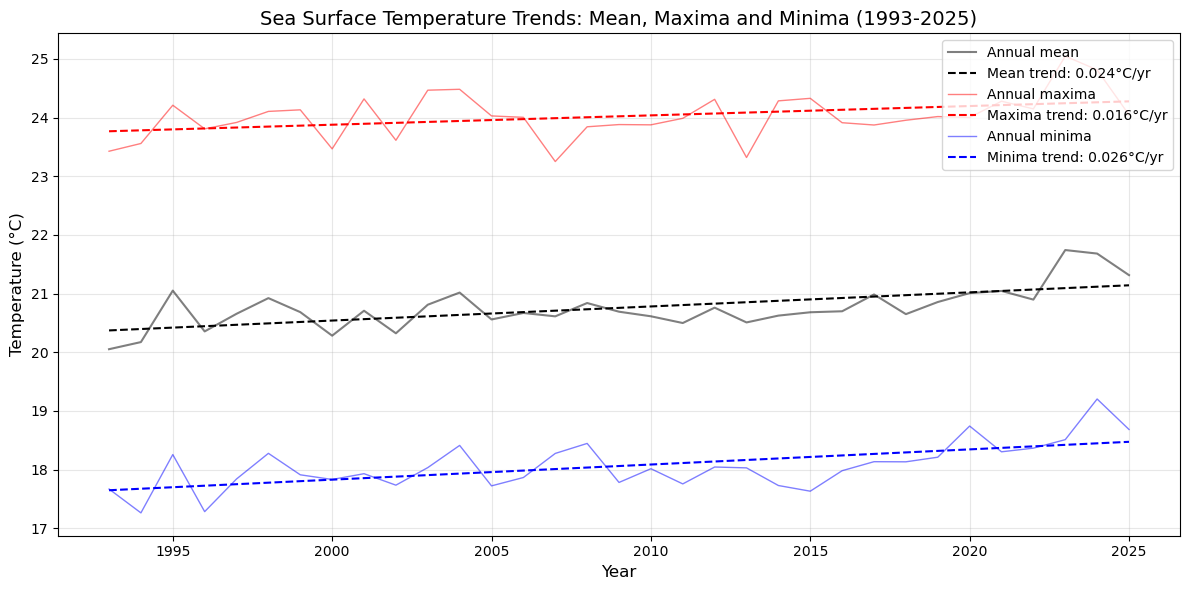


SUMMARY TABLE
       Metric  Slope (°C/yr)       r²  p-value  Standard Error
  Annual Mean       0.024038 0.407176 0.000065        0.005209
Annual Maxima       0.015927 0.156120 0.022860        0.006651
Annual Minima       0.025798 0.381513 0.000128        0.005899


In [28]:
# 6. Print results in English
print("="*60)
print("TEMPERATURE TREND ANALYSIS")
print("="*60)
print(f"Annual mean: {slopeT:.4f} °C/yr (r²={rT**2:.3f}, p={pT:.4f})")
print(f"Annual maxima: {slope_max:.4f} °C/yr (r²={r_max**2:.3f}, p={p_max:.4f})")
print(f"Annual minima: {slope_min:.4f} °C/yr (r²={r_min**2:.3f}, p={p_min:.4f})")

# Check if trends are significantly different
print("\nINTERPRETATION:")
if abs(slope_max - slope_min) < 0.001:
    print("• Maxima and minima show similar warming rates → uniform warming")
elif slope_max > slope_min:
    print("• Maxima warming faster than minima → summers warming more rapidly")
else:
    print("• Minima warming faster than maxima → winters warming more rapidly")

# 7. Comparative plot with English labels
fig, ax = plt.subplots(figsize=(12, 6))

# Annual mean
ax.plot(years_annual, temp_annual, 'k-', linewidth=1.5, alpha=0.5, label='Annual mean')
ax.plot(years_annual, slopeT*years_annual + interceptT, 'k--', 
        label=f'Mean trend: {slopeT:.3f}°C/yr')

# Annual maxima
ax.plot(years_tmax, tmax_annual, 'r-', linewidth=1, alpha=0.5, label='Annual maxima')
ax.plot(years_tmax, slope_max*years_tmax + intercept_max, 'r--', 
        label=f'Maxima trend: {slope_max:.3f}°C/yr')

# Annual minima
ax.plot(years_tmin, tmin_annual, 'b-', linewidth=1, alpha=0.5, label='Annual minima')
ax.plot(years_tmin, slope_min*years_tmin + intercept_min, 'b--', 
        label=f'Minima trend: {slope_min:.3f}°C/yr')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Sea Surface Temperature Trends: Mean, Maxima and Minima (1993-2025)', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temperature_trends_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 8. Optional: Export results to CSV for reporting
import pandas as pd

results_df = pd.DataFrame({
    'Metric': ['Annual Mean', 'Annual Maxima', 'Annual Minima'],
    'Slope (°C/yr)': [slope_mean, slope_max, slope_min],
    'r²': [r_mean**2, r_max**2, r_min**2],
    'p-value': [p_mean, p_max, p_min],
    'Standard Error': [se_mean, se_max, se_min]
})

print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(results_df.to_string(index=False))

# Optional: Save to file
# results_df.to_csv('temperature_trend_results.csv', index=False)

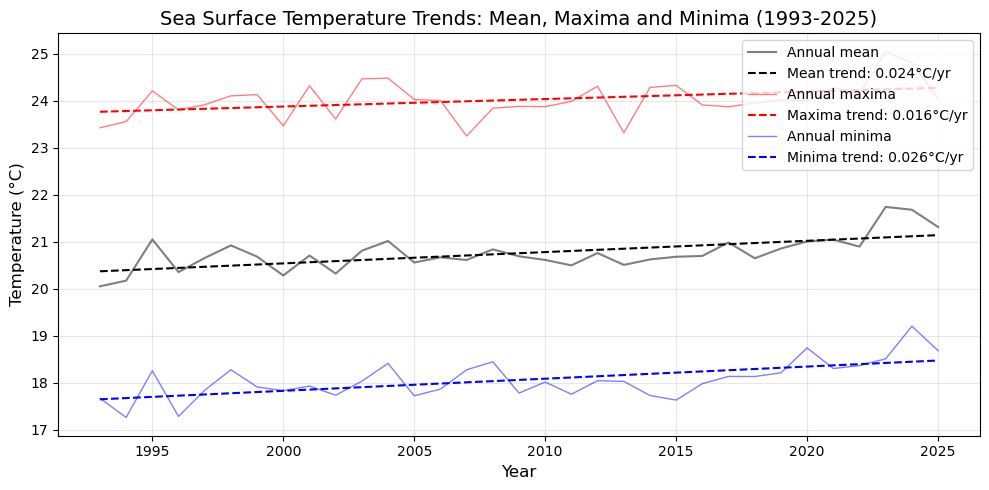

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

# Annual mean
ax.plot(years_annual, temp_annual, 'k-', linewidth=1.5, alpha=0.5, label='Annual mean')
ax.plot(years_annual, slopeT*years_annual + interceptT, 'k--', 
        label=f'Mean trend: {slopeT:.3f}°C/yr')

# Annual maxima
ax.plot(years_tmax, tmax_annual, 'r-', linewidth=1, alpha=0.5, label='Annual maxima')
ax.plot(years_tmax, slope_max*years_tmax + intercept_max, 'r--', 
        label=f'Maxima trend: {slope_max:.3f}°C/yr')

# Annual minima
ax.plot(years_tmin, tmin_annual, 'b-', linewidth=1, alpha=0.5, label='Annual minima')
ax.plot(years_tmin, slope_min*years_tmin + intercept_min, 'b--', 
        label=f'Minima trend: {slope_min:.3f}°C/yr')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Sea Surface Temperature Trends: Mean, Maxima and Minima (1993-2025)', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temperature_trends_comparisonTaller.png', dpi=300, bbox_inches='tight')
plt.show()

In [163]:
ds_avg_y['thetao']

<xarray.DataArray 'thetao' (year: 33)> Size: 264B
array([20.05120013, 20.17260498, 21.0498347 , 20.35440093, 20.65480033,
       20.92205483, 20.68316167, 20.28181091, 20.70696275, 20.32220131,
       20.8094776 , 21.01658409, 20.55807478, 20.66881374, 20.61138373,
       20.83835107, 20.69036988, 20.61235855, 20.49742404, 20.75925586,
       20.50757591, 20.62376753, 20.68081867, 20.6978406 , 20.9844522 ,
       20.64883468, 20.85527834, 21.00729895, 21.04399369, 20.89669449,
       21.74130482, 21.68127564, 21.31371802])
Coordinates:
    depth    float32 4B 0.494
  * year     (year) int64 264B 1993 1994 1995 1996 1997 ... 2022 2023 2024 2025

In [39]:
slopeT, interceptT, rT, pT, seT = linregress(ds_avg_y.year.data,  ds_avg_y.thetao.data)
trend_valsT = ds_avg_y.year.data*slopeT + interceptT

In [42]:
print(slopeT, interceptT, rT, pT, seT)
print(pT)

0.0240380693883284 -27.53660323648876 0.6381035498689557 6.467263358712412e-05 0.00520943248837783
6.467263358712412e-05


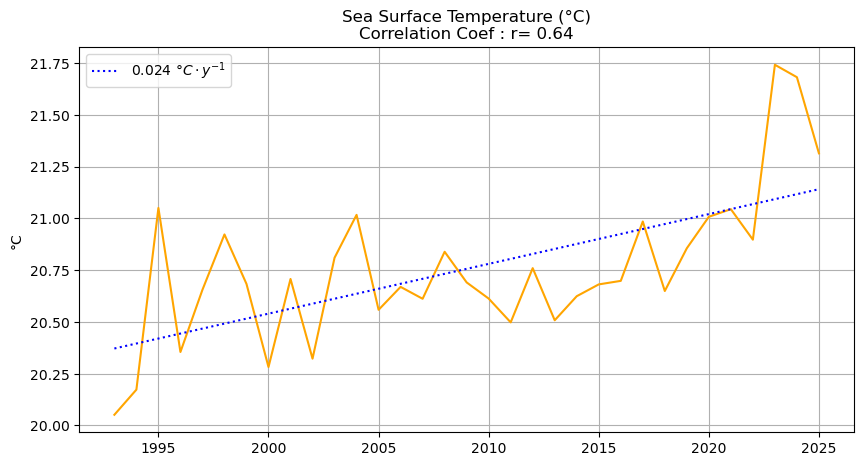

In [48]:
#slope, intercept, r, p, se = linregress(ds_avg_y.year.data,  ds_avg_y.thetao.data)
#trend_vals = ds_avg_y.year.data*slope + intercept


fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ds_avg_y.year.data, ds_avg_y.thetao.data, color='orange')
ax.plot(ds_avg_y.year.data, trend_valsT, color='b', linestyle=':', label='%.3f $°C \cdot y^{-1}$' % slopeT)       #C.{y^-1}
ax.set_title('Sea Surface Temperature (°C)\nCorrelation Coef : r= %.2f' %rT)
ax.set_ylabel('°C')
ax.grid(True)
ax.legend()

fig.savefig('SST.svg')
fig.savefig('SST.pdf')
fig.savefig('SST.png')
